# 03 — Model Training and Evaluation

**Phase:** Train/Test Split → Pipeline → Model Training → Evaluation → Insights

**Prerequisite:** You must run `01_data_preprocessing.ipynb` first to generate `flight_data_cleaned.csv`.

**What this notebook does:**
1. Loads clean CSV and prepares features
2. Builds a preprocessing pipeline (imputation + scaling + one-hot encoding)
3. Trains 5 models: Linear, Ridge, Lasso, Decision Tree, Random Forest
4. Compares using R², RMSE, MAE, MAPE
5. Diagnoses residuals and extracts feature importance
6. Synthesizes business insights


In [1]:
import warnings
warnings.filterwarnings('ignore')

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

print('All libraries imported successfully')

All libraries imported successfully


In [2]:
# Load clean data
DATA_PATH = r'D:\MS_Data_Science_Arden_university\Machine learning\ML_portfolio\ML_Project_report\data\flight_data_cleaned.csv'
df = pd.read_csv(DATA_PATH)

print(f'Loaded: {df.shape}')

# Define features and target
categorical_features = ['airline', 'source_city', 'departure_time', 'stops', 
                       'arrival_time', 'destination_city', 'class', 'route', 'duration_bucket']
numerical_features = ['days_left', 'duration_minutes']
target = 'price'

# Optional: sample for faster training (set to None to use full data)
TRAINING_SAMPLE_SIZE = 50000
if TRAINING_SAMPLE_SIZE and TRAINING_SAMPLE_SIZE < len(df):
    df = df.sample(TRAINING_SAMPLE_SIZE, random_state=SEED).copy()
    print(f'Sampled to {len(df)} rows for faster training')

X = df[categorical_features + numerical_features]
y = df[target]

print(f'Features: {X.shape[1]} | Target: {target}')

Loaded: (297936, 17)
Sampled to 50000 rows for faster training
Features: 11 | Target: price


## 1. Train/Test Split and Preprocessing Pipeline

**Critical rule:** Fit preprocessing ONLY on training data to prevent data leakage.

In [3]:
# 70/30 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=SEED)

# Log-transform target for training stability (reduces skewness)
USE_LOG_TARGET = True
y_train_model = np.log1p(y_train)
y_test_model = np.log1p(y_test)

# Numeric pipeline: impute missing with median, then scale
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute missing with mode, then one-hot encode
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine pipelines
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Fit on training data only, then transform both sets
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print(f'Train shape: {X_train.shape} | Test shape: {X_test.shape}')
print(f'Prepared matrix shape: {X_train_prepared.shape}')
print(f'Target transform: log1p({target})')

Train shape: (35000, 11) | Test shape: (15000, 11)
Prepared matrix shape: (35000, 71)
Target transform: log1p(price)


## 2. Model Training

Train 5 models: Linear (baseline), Ridge (L2), Lasso (L1), Decision Tree, Random Forest (ensemble).

In [4]:
# Define models
model_specs = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=SEED),
    'Lasso Regression': Lasso(alpha=0.1, max_iter=1500, tol=5e-3, selection='random', random_state=SEED),
    'Decision Tree': DecisionTreeRegressor(random_state=SEED, max_depth=20, min_samples_leaf=5),
    'Random Forest': RandomForestRegressor(
        random_state=SEED, n_estimators=30, max_depth=None, min_samples_leaf=2, n_jobs=-1
    )
}

trained_models = {}
for name, estimator in model_specs.items():
    estimator.fit(X_train_prepared, y_train_model)
    trained_models[name] = estimator
    print(f'Trained: {name}')

Trained: Linear Regression
Trained: Ridge Regression
Trained: Lasso Regression
Trained: Decision Tree
Trained: Random Forest


## 3. Model Evaluation

Compare all models using 4 metrics:
- **R²**: Variance explained (1.0 = perfect)
- **RMSE**: Typical error in INR
- **MAE**: Average absolute error
- **MAPE**: Relative error percentage

In [5]:
evaluation_rows = []
predictions = {}

for model_name, estimator in trained_models.items():
    # Predict on log scale, then convert back
    y_pred_model = estimator.predict(X_test_prepared)
    y_pred = np.expm1(y_pred_model) if USE_LOG_TARGET else y_pred_model
    predictions[model_name] = y_pred

    evaluation_rows.append({
        'model': model_name,
        'r2': round(r2_score(y_test, y_pred), 4),
        'rmse': round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
        'mae': round(mean_absolute_error(y_test, y_pred), 2),
        'mape': round(mean_absolute_percentage_error(y_test, y_pred), 4)
    })

evaluation_df = pd.DataFrame(evaluation_rows).sort_values('r2', ascending=False)
print('Model Comparison Results:')
display(evaluation_df)

best_model_name = evaluation_df.iloc[0]['model']
print(f'🏆 Best Model: {best_model_name}')

Model Comparison Results:


,model,r2,rmse,mae,mape
4,Random Forest,0.9783,3378.30,1645.90,0.1056
3,Decision Tree,0.9681,4094.36,2109.96,0.1341
0,Linear Regression,0.8836,7817.86,4621.47,0.2595
1,Ridge Regression,0.8836,7817.38,4621.28,0.2595
2,Lasso Regression,0.7346,11805.04,7102.17,0.4208


🏆 Best Model: Random Forest


## 4. Residual Diagnostics (Best Model)

Residuals = Actual - Predicted. Good residuals are:
- Scattered randomly around zero
- Normally distributed
- No obvious patterns

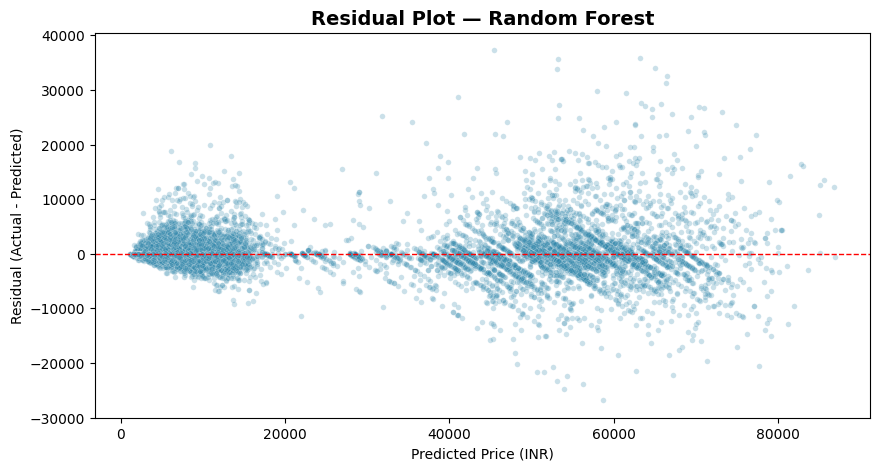

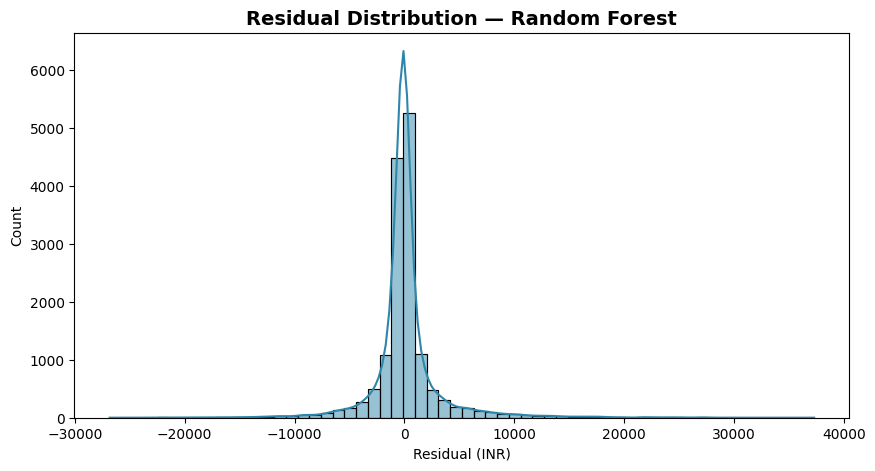

Mean residual: 163.90
Std residual: 3374.43
Interpretation: Near-zero mean = minimal systematic bias.


In [6]:
best_model = trained_models[best_model_name]
best_pred = predictions[best_model_name]
residuals = y_test - best_pred

# Residual scatter plot
plt.figure(figsize=(10, 5))
sns.scatterplot(x=best_pred, y=residuals, alpha=0.25, s=16, color='#2E86AB')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title(f'Residual Plot — {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Price (INR)')
plt.ylabel('Residual (Actual - Predicted)')
plt.show()

# Residual distribution
plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=60, kde=True, color='#2E86AB')
plt.title(f'Residual Distribution — {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Residual (INR)')
plt.ylabel('Count')
plt.show()

print(f'Mean residual: {residuals.mean():.2f}')
print(f'Std residual: {residuals.std():.2f}')
print('Interpretation: Near-zero mean = minimal systematic bias.')

## 5. Feature Importance (Random Forest)

Which variables matter most for price prediction?

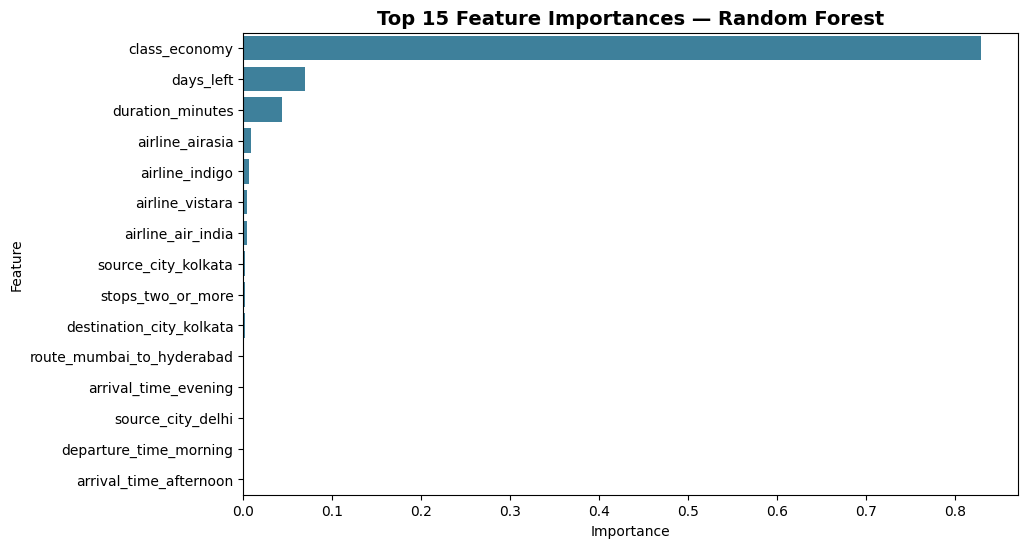

Top 15 Feature Importances:


,feature,importance
36,class_economy,0.829901
0,days_left,0.069633
1,duration_minutes,0.043993
3,airline_airasia,0.008876
5,airline_indigo,0.006983
7,airline_vistara,0.003848
2,airline_air_india,0.003739
12,source_city_kolkata,0.002321
21,stops_two_or_more,0.002178
33,destination_city_kolkata,0.001917


Insight: class_economy dominates with 83.0% of predictive power.


In [7]:
# Get feature names after one-hot encoding
cat_ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_ohe.get_feature_names_out(categorical_features)
all_feature_names = list(numerical_features) + list(cat_feature_names)

# Extract importances
feature_importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 15
plt.figure(figsize=(10, 6))
top_15 = feature_importance_df.head(15)
sns.barplot(data=top_15, y='feature', x='importance', color='#2E86AB')
plt.title('Top 15 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

print('Top 15 Feature Importances:')
display(top_15)

print(f'Insight: {top_15.iloc[0]["feature"]} dominates with {top_15.iloc[0]["importance"]:.1%} of predictive power.')

## 6. Actual vs Predicted Plot

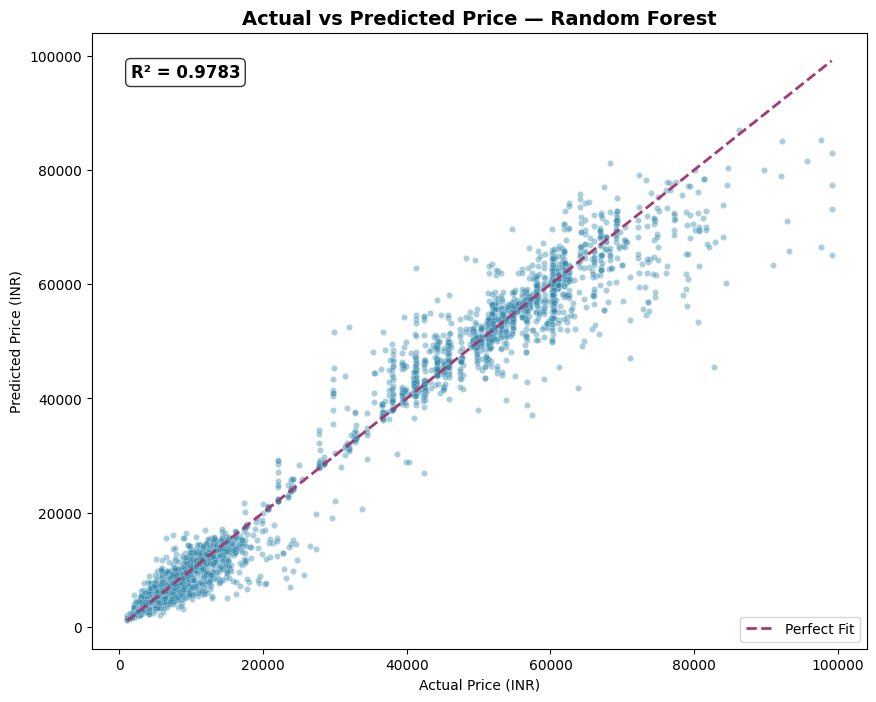

R² = 0.9783 means the model explains 97.8% of price variance.


In [8]:
sample_size = min(5000, len(y_test))
sample_idx = np.random.choice(len(y_test), size=sample_size, replace=False)
y_test_sample = y_test.iloc[sample_idx]
best_pred_sample = best_pred[sample_idx]

plt.figure(figsize=(10, 8))
plt.scatter(y_test_sample, best_pred_sample, alpha=0.4, s=20, color='#2E86AB', edgecolor='white', linewidth=0.3)

# Perfect fit line
min_val = min(y_test_sample.min(), best_pred_sample.min())
max_val = max(y_test_sample.max(), best_pred_sample.max())
plt.plot([min_val, max_val], [min_val, max_val], color='#A23B72', linestyle='--', linewidth=2, label='Perfect Fit')

# R² annotation
r2 = r2_score(y_test, best_pred)
plt.text(0.05, 0.95, f'R² = {r2:.4f}', transform=plt.gca().transAxes, fontsize=12, fontweight='bold',
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.title('Actual vs Predicted Price — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Actual Price (INR)')
plt.ylabel('Predicted Price (INR)')
plt.legend()
plt.show()

print(f'R² = {r2:.4f} means the model explains {r2:.1%} of price variance.')

## 7. Key Insights Summary

In [10]:
# Calculate key statistics for insights
business_avg = df.loc[df['class'] == 'business', 'price'].mean()
economy_avg = df.loc[df['class'] == 'economy', 'price'].mean()
class_premium = ((business_avg - economy_avg) / economy_avg) * 100

days_left_corr = df[['days_left', 'price']].corr().loc['days_left', 'price']

airline_avg = df.groupby('airline')['price'].mean().sort_values(ascending=False)

insights = pd.DataFrame([
    {
        'question': 'Why is business class more expensive?',
        'evidence': f'Business mean is {class_premium:.1f}% above economy (₹{business_avg:,.0f} vs ₹{economy_avg:,.0f})'
    },
    {
        'question': 'Do fewer days to departure increase price?',
        'evidence': f'Correlation(days_left, price) = {days_left_corr:.3f} (negative = late booking costs more)'
    },
    {
        'question': 'Which airlines tend to be highest priced?',
        'evidence': f'Top: {airline_avg.index[0]} (₹{airline_avg.iloc[0]:,.0f}), {airline_avg.index[1]} (₹{airline_avg.iloc[1]:,.0f})'
    },
    {
        'question': 'Which variables increase/decrease ticket price?',
        'evidence': f'Top drivers: {top_15.iloc[0]["feature"]} ({top_15.iloc[0]["importance"]:.1%}), {top_15.iloc[1]["feature"]} ({top_15.iloc[1]["importance"]:.1%})'
    }
])

print('=== KEY INSIGHTS ===')
display(insights)

print('=== TOP 5 AIRLINES BY AVERAGE PRICE ===')
display(airline_avg.head().to_frame('avg_price'))

print('✅ Notebook 03 complete. All 3 notebooks finished!')

=== KEY INSIGHTS ===


,question,evidence
0,Why is business class more expensive?,"Business mean is 699.5% above economy (₹52,584..."
1,Do fewer days to departure increase price?,"Correlation(days_left, price) = -0.096 (negati..."
2,Which airlines tend to be highest priced?,"Top: vistara (₹30,404), air_india (₹23,314)"
3,Which variables increase/decrease ticket price?,"Top drivers: class_economy (83.0%), days_left ..."


=== TOP 5 AIRLINES BY AVERAGE PRICE ===


,avg_price
airline,
vistara,30404.227375
air_india,23314.460187
spicejet,6196.872651
go_first,5737.139744
indigo,5313.802192


✅ Notebook 03 complete. All 3 notebooks finished!
